### Mini Project: COVID-19 Detection from Chest X-rays using CNN

Name: Bhushan Mandekar

Batch - 14

Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


Dataset Path

In [2]:
import os

train_dir = "archive/Covid19-dataset/train"
test_dir = "archive/Covid19-dataset/test"

covid_path = os.path.join(train_dir, "Covid")
normal_path = os.path.join(train_dir, "Normal")
viral_path = os.path.join(train_dir, "Viral Pneumonia")

Count Images

In [3]:
print("COVID Images :", len(os.listdir(covid_path)))
print("Normal Images :", len(os.listdir(normal_path)))
print("Viral Pneumonia Images :", len(os.listdir(viral_path)))

COVID Images : 111
Normal Images : 70
Viral Pneumonia Images : 70


Define Image Size

In [4]:
IMG_SIZE = 224

Load Training Images

In [5]:
X = []
y = []

categories = [
    ("Covid", 0),
    ("Normal", 1),
    ("Viral Pneumonia", 2)
]

for folder_name, label in categories:

    folder_path = os.path.join(train_dir, folder_name)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        X.append(image)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Training Images:", X.shape)
print("Training Labels:", y.shape)

Training Images: (251, 224, 224, 3)
Training Labels: (251,)


Load Test Images

In [6]:
X_test = []
y_test = []

for folder_name, label in categories:

    folder_path = os.path.join(test_dir, folder_name)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        X_test.append(image)
        y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Testing Images: (66, 224, 224, 3)
Testing Labels: (66,)


Normalize Images

In [7]:
X = X.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

Check the range:

In [8]:
print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


One-Hot Encode Labels

In [9]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

print(y.shape)
print(y_test.shape)

(251, 3)
(66, 3)


Split Training and Validation Sets

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Validation Set :", X_val.shape)
print("Testing Set :", X_test.shape)

Training Set : (200, 224, 224, 3)
Validation Set : (51, 224, 224, 3)
Testing Set : (66, 224, 224, 3)


Verify Class Distribution

In [11]:
class_names = ["Covid", "Normal", "Viral Pneumonia"]

for i, class_name in enumerate(class_names):
    print(f"{class_name}: {(np.argmax(y_train, axis=1) == i).sum()}")

Covid: 88
Normal: 56
Viral Pneumonia: 56


Exploratory Data Analysis (EDA)

Class Distribution

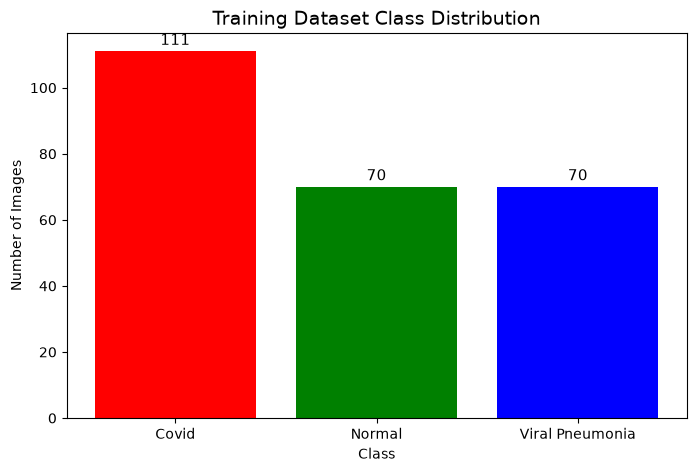

In [12]:
class_names = ["Covid", "Normal", "Viral Pneumonia"]

train_counts = [
    len(os.listdir(os.path.join(train_dir, "Covid"))),
    len(os.listdir(os.path.join(train_dir, "Normal"))),
    len(os.listdir(os.path.join(train_dir, "Viral Pneumonia")))
]

plt.figure(figsize=(8,5))
plt.bar(class_names, train_counts, color=["red", "green", "blue"])

plt.title("Training Dataset Class Distribution", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, count in enumerate(train_counts):
    plt.text(i, count + 2, str(count), ha='center', fontsize=11)

plt.show()

Pie Chart of Class Distribution

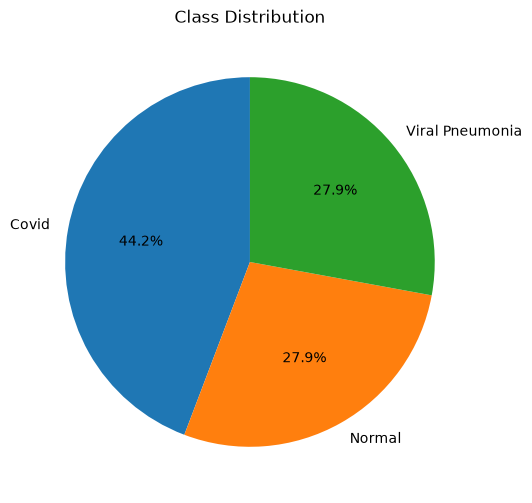

In [13]:
plt.figure(figsize=(6,6))

plt.pie(
    train_counts,
    labels=class_names,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution")
plt.show()

Display Random Sample Images

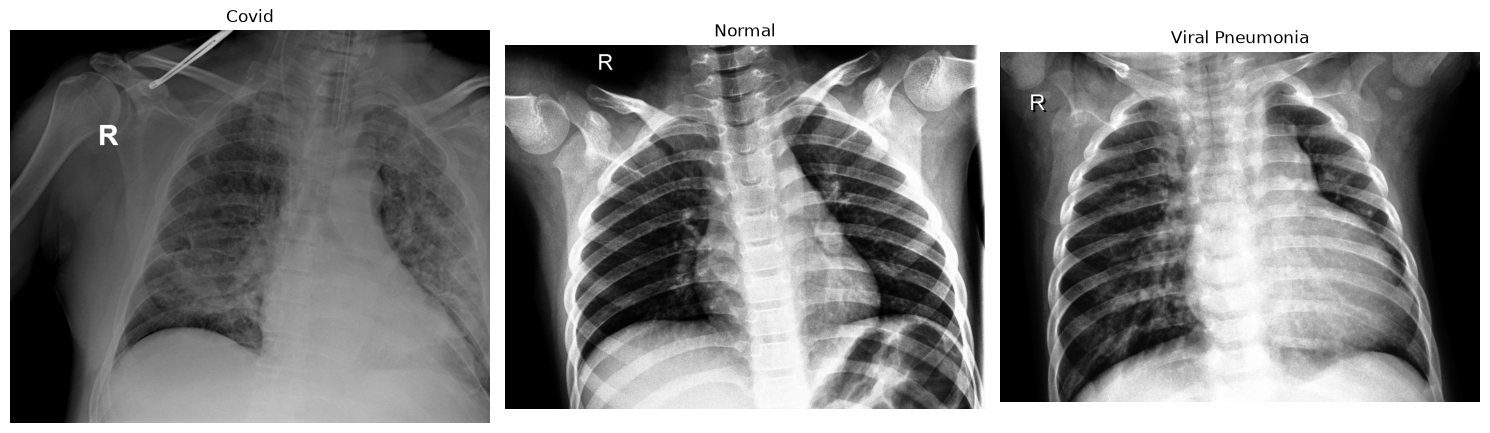

In [14]:
import random

plt.figure(figsize=(15,10))

for i, class_name in enumerate(class_names):

    folder = os.path.join(train_dir, class_name)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Display Multiple Random Images

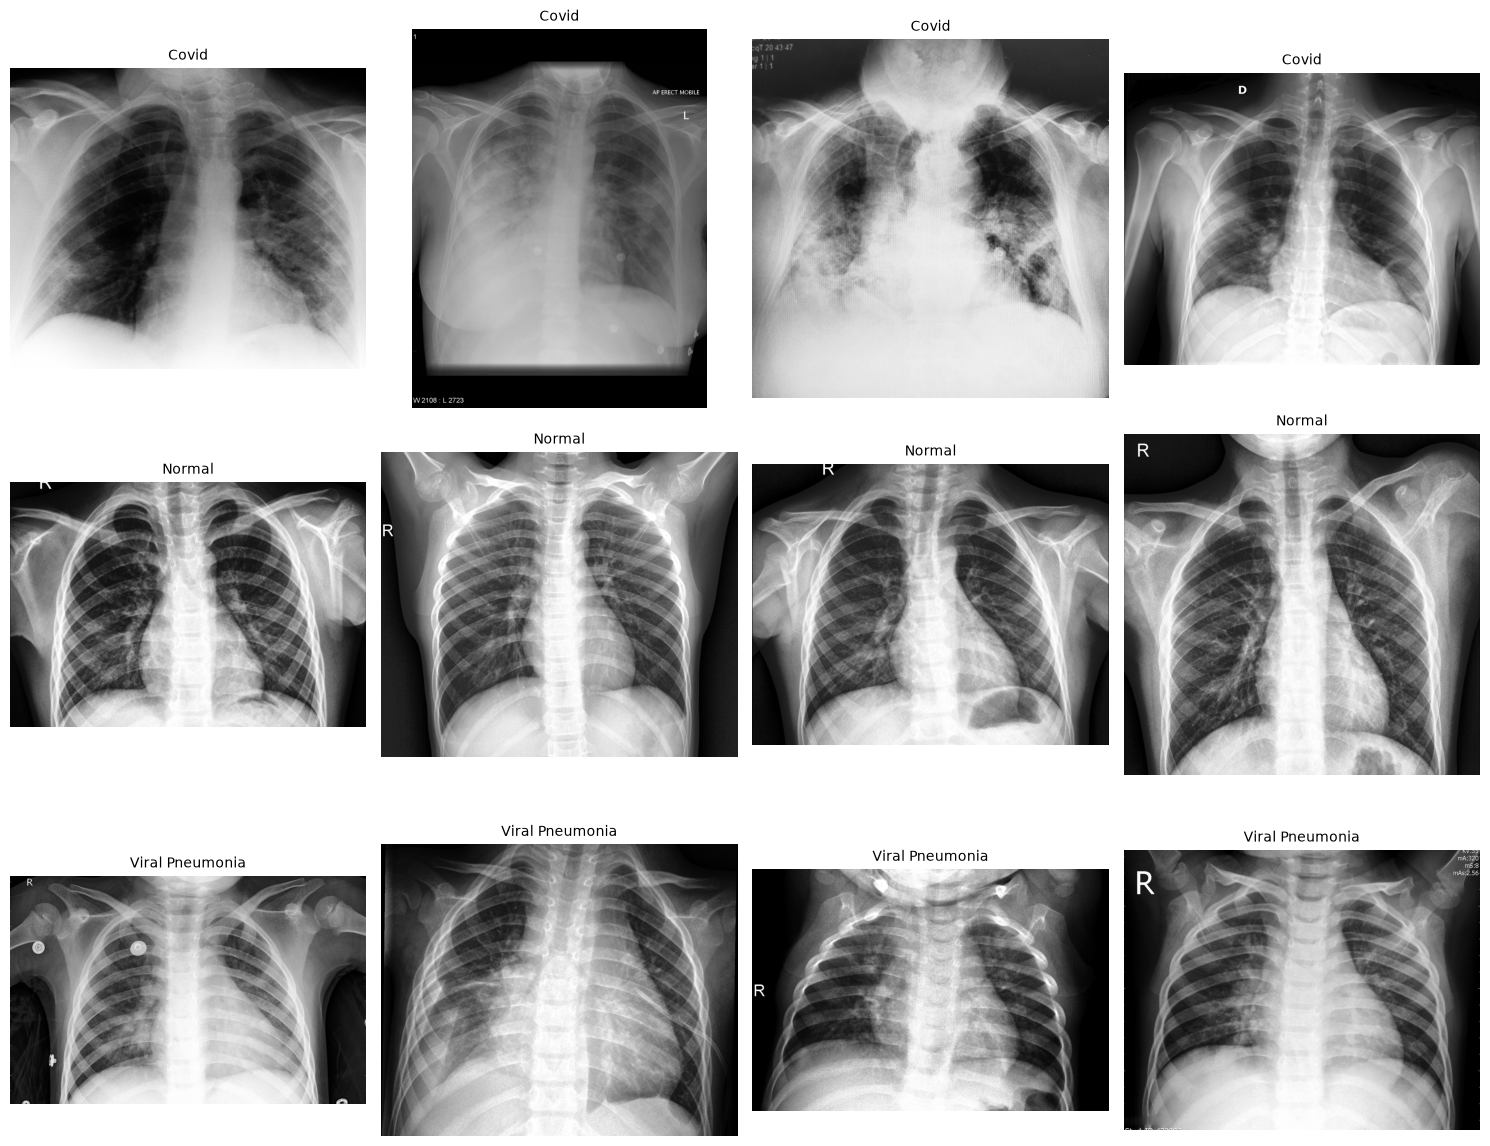

In [15]:
plt.figure(figsize=(15,12))

image_number = 1

for class_name in class_names:

    folder = os.path.join(train_dir, class_name)

    random_images = random.sample(os.listdir(folder), 4)

    for image_name in random_images:

        image_path = os.path.join(folder, image_name)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(3,4,image_number)
        plt.imshow(image)
        plt.title(class_name, fontsize=10)
        plt.axis("off")

        image_number += 1

plt.tight_layout()
plt.show()

Image Shape

In [16]:
print("Image Shape:", X_train[0].shape)

Image Shape: (224, 224, 3)


Pixel Value Distribution

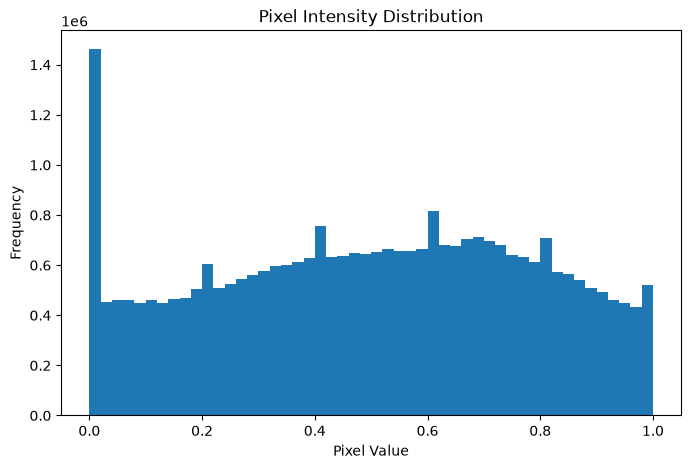

In [17]:
plt.figure(figsize=(8,5))

plt.hist(X_train.ravel(), bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

Class Distribution Using Seaborn

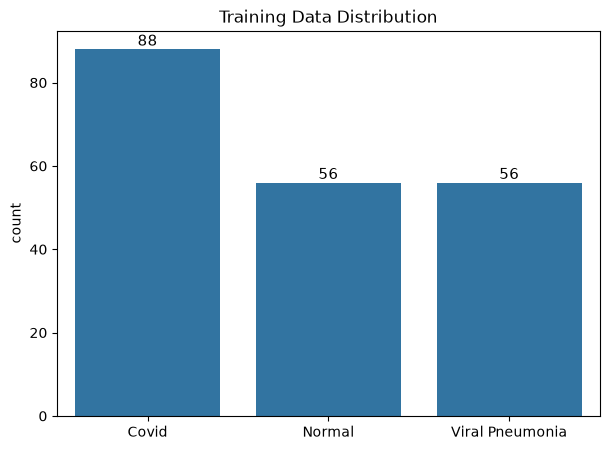

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = np.argmax(y_train, axis=1)

plt.figure(figsize=(7,5))

ax = sns.countplot(x=labels)

plt.xticks([0, 1, 2], class_names)
plt.title("Training Data Distribution")

# Add count labels on top of each bar
ax.bar_label(ax.containers[0], fontsize=11)

plt.show()

#### Model 1: Basic CNN

Import Required Layers

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

Build the CNN Model

In [20]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(3, activation="softmax")

])

d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Display Model Summary

In [21]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,278,851 (84.99 MB)

 Trainable params: 22,278,403 (84.99 MB)

 Non-trainable params: 448 (1.75 KB)

Compile the Model

In [22]:
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Create Model Folder

In [23]:
os.makedirs("models", exist_ok=True)

Define Callbacks

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "models/basic_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True
)

Train the Model

In [25]:
history = cnn_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=20,

    batch_size=32,

    callbacks=[early_stop, checkpoint],

    verbose=1

)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 847ms/step - accuracy: 0.6800 - loss: 7.5566 - val_accuracy: 0.2745 - val_loss: 4.6790
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 816ms/step - accuracy: 0.7950 - loss: 7.1557 - val_accuracy: 0.5098 - val_loss: 1.1371
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 723ms/step - accuracy: 0.9050 - loss: 3.0321 - val_accuracy: 0.4510 - val_loss: 7.6969
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 747ms/step - accuracy: 0.8950 - loss: 4.8040 - val_accuracy: 0.4510 - val_loss: 41.8808
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 708ms/step - accuracy: 0.8750 - loss: 6.3414 - val_accuracy: 0.4510 - val_loss: 55.6953
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 733ms/step - accuracy: 0.9350 - loss: 2.0602 - val_accuracy: 0.4510 - val_loss: 66.1570
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 728ms/step - accuracy: 0.9150 - loss: 2.2373 - val_accuracy: 0.4510 - val_loss: 70.9873


Plot Accuracy

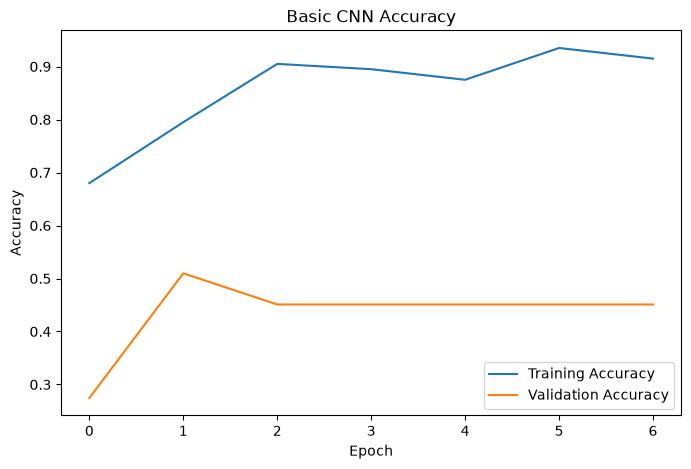

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Basic CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Plot Loss

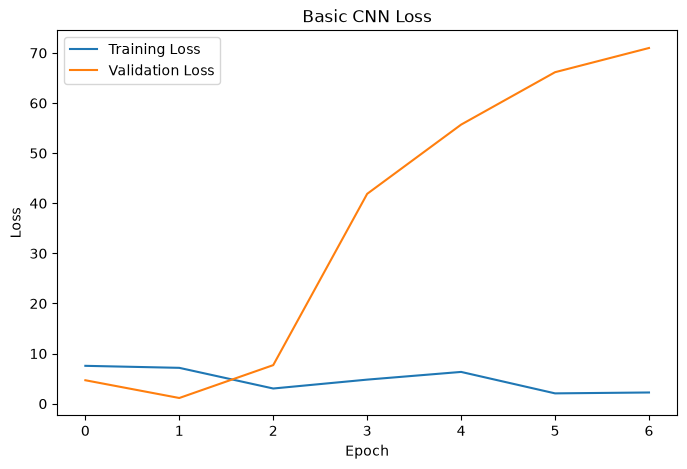

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Basic CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Evaluate on Test Set

In [28]:
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3182 - loss: 1.4716 
Test Loss : 1.471616268157959
Test Accuracy : 0.3181818127632141


Predictions

In [29]:
y_pred = cnn_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


Confusion Matrix

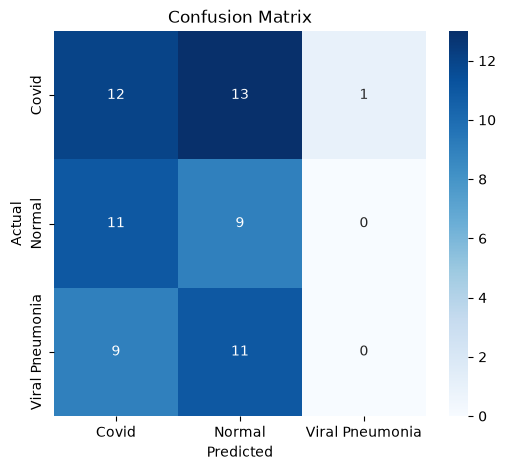

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Classification Report

In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

                 precision    recall  f1-score   support

          Covid       0.38      0.46      0.41        26
         Normal       0.27      0.45      0.34        20
Viral Pneumonia       0.00      0.00      0.00        20

       accuracy                           0.32        66
      macro avg       0.22      0.30      0.25        66
   weighted avg       0.23      0.32      0.27        66



ROC-AUC Score

In [32]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred,
    multi_class="ovr"
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5488154960981049


#### Model 2: VGG16 Transfer Learning

Import VGG16

In [33]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten
)

Load Pre-trained VGG16

In [34]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

Freeze the Base Model

In [35]:
for layer in base_model.layers:
    layer.trainable = False

Build the VGG16 Model

In [36]:
x = base_model.output

x = Flatten()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

predictions = Dense(3, activation="softmax")(x)

vgg_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

Model Summary

In [37]:
vgg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           38

 Total params: 21,170,755 (80.76 MB)

 Trainable params: 6,456,067 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Compile the Model

In [38]:
vgg_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Callbacks

In [39]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "models/vgg16_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

Train VGG16

In [40]:
history_vgg = vgg_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=20,

    batch_size=32,

    callbacks=[early_stop, checkpoint],

    verbose=1

)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.3950 - loss: 2.4190 - val_accuracy: 0.6863 - val_loss: 0.6119
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6200 - loss: 1.5071 - val_accuracy: 0.8824 - val_loss: 0.2642
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7400 - loss: 0.6683 - val_accuracy: 0.9020 - val_loss: 0.2719
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8450 - loss: 0.5093 - val_accuracy: 0.8627 - val_loss: 0.3086
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8600 - loss: 0.4846 - val_accuracy: 0.9020 - val_loss: 0.2204
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8550 - loss: 0.3000 - val_accuracy: 0.9608 - val_loss: 0.1876
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9150 - loss: 0.2230 - val_accuracy: 0.9020 - val_loss: 0.2738
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9050 - loss: 0.2840 - val_accuracy: 0.9216 - val_loss: 0.2132
Epoch 9/

Accuracy Plot

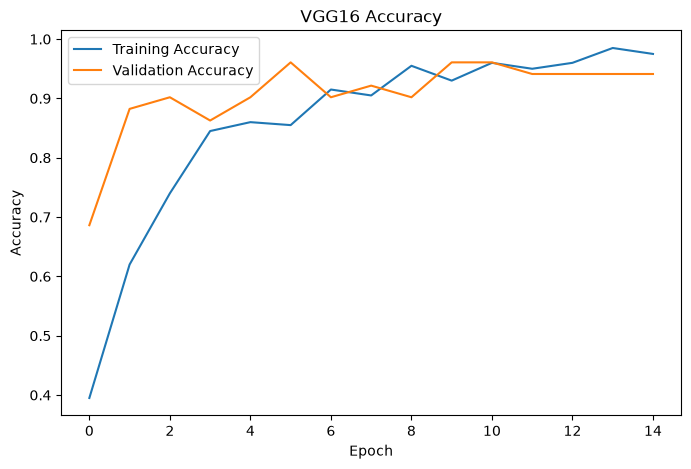

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history["accuracy"], label="Training Accuracy")
plt.plot(history_vgg.history["val_accuracy"], label="Validation Accuracy")

plt.title("VGG16 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

Loss Plot

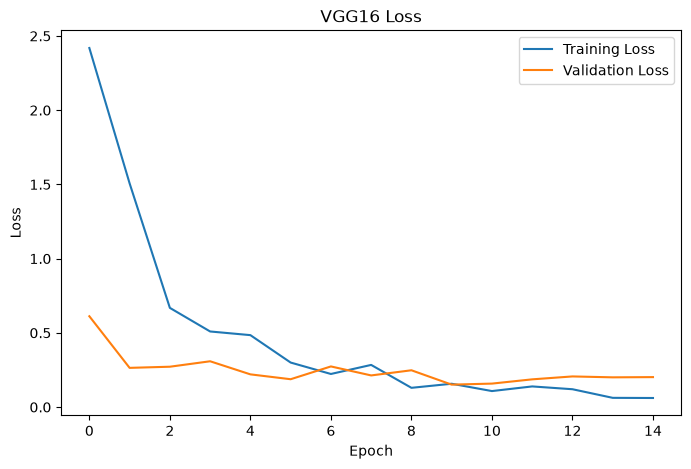

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history_vgg.history["loss"], label="Training Loss")
plt.plot(history_vgg.history["val_loss"], label="Validation Loss")

plt.title("VGG16 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

Evaluate Model

In [43]:
test_loss, test_accuracy = vgg_model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9091 - loss: 0.1732
Test Loss : 0.1731601506471634
Test Accuracy : 0.9090909361839294


Predictions

In [44]:
y_pred = vgg_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step


Confusion Matrix

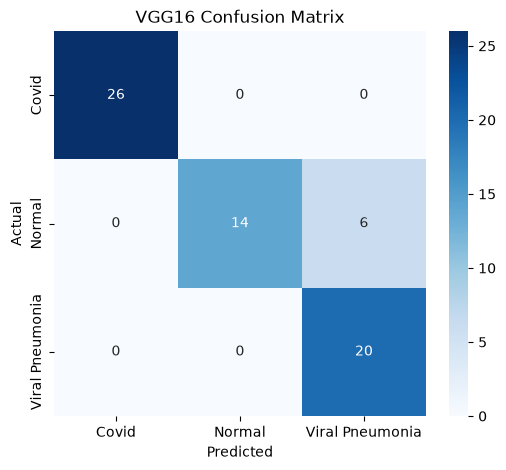

In [45]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("VGG16 Confusion Matrix")

plt.show()

Classification Report

In [46]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

                 precision    recall  f1-score   support

          Covid       1.00      1.00      1.00        26
         Normal       1.00      0.70      0.82        20
Viral Pneumonia       0.77      1.00      0.87        20

       accuracy                           0.91        66
      macro avg       0.92      0.90      0.90        66
   weighted avg       0.93      0.91      0.91        66



ROC-AUC Score

In [47]:
roc_auc = roc_auc_score(
    y_test,
    y_pred,
    multi_class="ovr"
)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.9952898550724637


#### Model 3: ResNet50 + Data Augmentation

Import ResNet50

In [48]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

Create ImageDataGenerator

In [49]:
train_datagen = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    fill_mode="nearest"

)

val_datagen = ImageDataGenerator()

Create Data Generators

In [50]:
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32,
    shuffle=True
)

validation_generator = val_datagen.flow(
    X_val,
    y_val,
    batch_size=32,
    shuffle=False
)

Load ResNet50

In [51]:
base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

Freeze Base Layers

In [52]:
for layer in base_model.layers:
    layer.trainable = False

Build Model

In [53]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

output = Dense(3, activation="softmax")(x)

resnet_model = Model(

    inputs=base_model.input,

    outputs=output

)

Model Summary

In [54]:
resnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,145,539 (92.11 MB)

 Trainable params: 557,827 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Compile Model

In [55]:
resnet_model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

Callbacks

In [56]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "models/resnet50_model.keras",

    monitor="val_accuracy",

    save_best_only=True

)

Train Model

In [57]:
history_resnet = resnet_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20,

    callbacks=[early_stop, checkpoint],

    verbose=1

)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.4100 - loss: 1.2110 - val_accuracy: 0.4510 - val_loss: 1.0778
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4050 - loss: 1.1854 - val_accuracy: 0.4510 - val_loss: 1.0776
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.4250 - loss: 1.1832 - val_accuracy: 0.4510 - val_loss: 1.0757
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3550 - loss: 1.1792 - val_accuracy: 0.4510 - val_loss: 1.0653
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3900 - loss: 1.1915 - val_accuracy: 0.4510 - val_loss: 1.0602
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.3750 - loss: 1.1813 - val_accuracy: 0.4510 - val_loss: 1.0587
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3600 - loss: 1.1719 - val_accuracy: 0.4510 - val_loss: 1.0602
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.3800 - loss: 1.1442 - val_accuracy: 0.4510 - val_loss: 1.0557
Epoch 9/20


Accuracy Plot

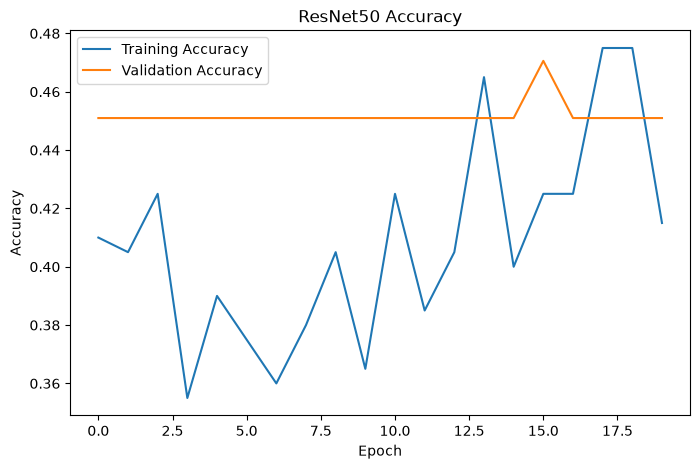

In [58]:
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history["accuracy"], label="Training Accuracy")

plt.plot(history_resnet.history["val_accuracy"], label="Validation Accuracy")

plt.title("ResNet50 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

Loss Plot

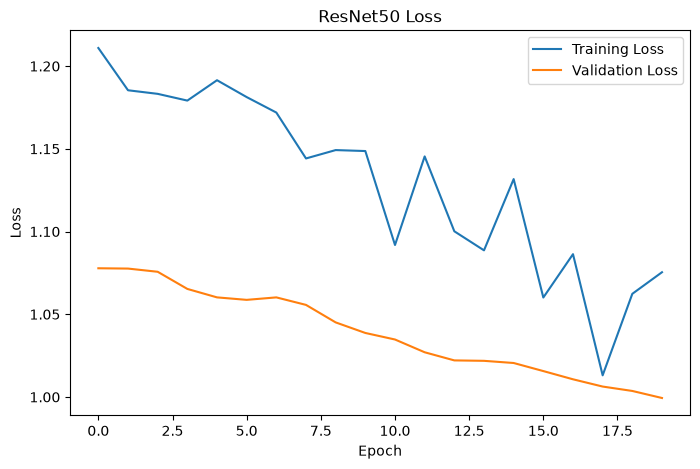

In [59]:
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history["loss"], label="Training Loss")

plt.plot(history_resnet.history["val_loss"], label="Validation Loss")

plt.title("ResNet50 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

Evaluate Model

In [60]:
test_loss, test_accuracy = resnet_model.evaluate(

    X_test,

    y_test

)

print("Test Loss :", test_loss)

print("Test Accuracy :", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 517ms/step - accuracy: 0.4697 - loss: 0.9973
Test Loss : 0.9972711205482483
Test Accuracy : 0.469696968793869


Predictions

In [61]:
y_pred = resnet_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000275314E8D60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  


Confusion Matrix

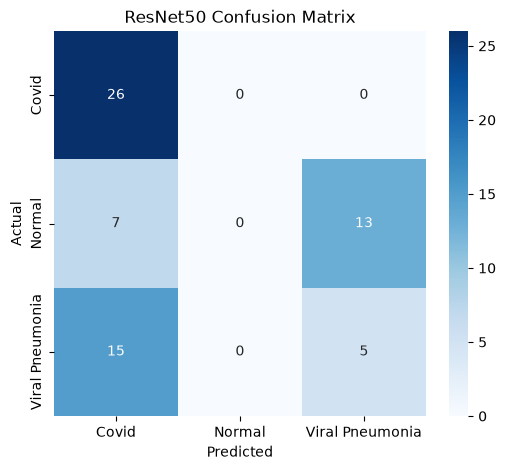

In [62]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("ResNet50 Confusion Matrix")

plt.show()

Classification Report

In [63]:
print(classification_report(

    y_true,

    y_pred_classes,

    target_names=class_names

))

                 precision    recall  f1-score   support

          Covid       0.54      1.00      0.70        26
         Normal       0.00      0.00      0.00        20
Viral Pneumonia       0.28      0.25      0.26        20

       accuracy                           0.47        66
      macro avg       0.27      0.42      0.32        66
   weighted avg       0.30      0.47      0.36        66



d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

ROC-AUC Score

In [64]:
roc_auc = roc_auc_score(

    y_test,

    y_pred,

    multi_class="ovr"

)

print("ROC-AUC Score :", roc_auc)

ROC-AUC Score : 0.8536510590858418


#### Handle Class Imbalance

Compute Class Weights

In [65]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.7575757575757576), 1: np.float64(1.1904761904761905), 2: np.float64(1.1904761904761905)}


If you retrain any model, include:

In [66]:
class_weight=class_weights

Example:

In [67]:
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 914ms/step - accuracy: 0.8550 - loss: 5.0840 - val_accuracy: 0.4510 - val_loss: 12.3161
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 835ms/step - accuracy: 0.8950 - loss: 2.9763 - val_accuracy: 0.4510 - val_loss: 29.9643
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 860ms/step - accuracy: 0.9150 - loss: 3.4978 - val_accuracy: 0.4510 - val_loss: 37.4996
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 874ms/step - accuracy: 0.9250 - loss: 2.2188 - val_accuracy: 0.4510 - val_loss: 44.5510
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 786ms/step - accuracy: 0.9050 - loss: 3.3935 - val_accuracy: 0.4510 - val_loss: 52.8205
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9600 - loss: 0.5475 - val_accuracy: 0.4510 - val_loss: 59.9812


#### Hyperparameter Tuning with Keras Tuner

Import Keras Tuner

In [68]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

Create Model Building Function

In [69]:
def build_model(hp):

    model = Sequential()

    model.add(
        Conv2D(
            filters=hp.Int("filters1", min_value=32, max_value=128, step=32),
            kernel_size=(3,3),
            activation="relu",
            input_shape=(224,224,3)
        )
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(
        Conv2D(
            filters=hp.Int("filters2", min_value=64, max_value=256, step=64),
            kernel_size=(3,3),
            activation="relu"
        )
    )

    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Flatten())

    model.add(
        Dense(
            units=hp.Int("dense_units", 64, 256, step=64),
            activation="relu"
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                min_value=0.2,
                max_value=0.5,
                step=0.1
            )
        )
    )

    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer=hp.Choice(
            "optimizer",
            values=["adam","rmsprop"]
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Create the Tuner

In [70]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="tuner_results",
    project_name="covid_detection"
)

Reloading Tuner from tuner_results\covid_detection\tuner0.json


Start Hyperparameter Search

In [71]:
tuner.search(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Best Hyperparameters

In [72]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Filters 1 :", best_hp.get("filters1"))
print("Best Filters 2 :", best_hp.get("filters2"))
print("Best Dense Units :", best_hp.get("dense_units"))
print("Best Dropout :", best_hp.get("dropout"))
print("Best Optimizer :", best_hp.get("optimizer"))

Best Filters 1 : 32
Best Filters 2 : 192
Best Dense Units : 192
Best Dropout : 0.4
Best Optimizer : adam


Train the Best Tuned Model

In [73]:
best_model = tuner.get_best_models(1)[0]

history_best = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop]
)

d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


d:\AIML\Data_science\Deployment\B14\myenv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(store)


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8450 - loss: 0.7067 - val_accuracy: 0.9216 - val_loss: 0.2047
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8950 - loss: 0.2434 - val_accuracy: 0.7647 - val_loss: 0.6970
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 930ms/step - accuracy: 0.9450 - loss: 0.1175 - val_accuracy: 0.8824 - val_loss: 0.2238
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9800 - loss: 0.0461 - val_accuracy: 0.9216 - val_loss: 0.2344
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 966ms/step - accuracy: 0.9900 - loss: 0.0255 - val_accuracy: 0.8824 - val_loss: 0.1922
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 53s 8s/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.8627 - val_loss: 0.4717
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.9020 - val_loss: 0.2370
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9020 - val_loss: 0.3417
Epoch 9/20
7/7 ━

Evaluate the Tuned Model

In [74]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)

print("Test Accuracy :", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9545 - loss: 0.1071 
Test Accuracy : 0.9545454382896423


In [75]:
# Predict probabilities
y_pred_prob = best_model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


In [76]:
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)


In [77]:
# Classification Report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       0.90      0.95      0.93        20
           2       0.95      0.90      0.92        20

    accuracy                           0.95        66
   macro avg       0.95      0.95      0.95        66
weighted avg       0.96      0.95      0.95        66



In [78]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.994927536231884


#### Model Comparison

Model Comparison Table

In [79]:
comparison = pd.DataFrame({

    "Model": [
        "Basic CNN",
        "VGG16",
        "ResNet50",
        "Best Tuned Model"
    ],

    "Train Accuracy": [
        0.9150,
        0.9750,
        0.4150,
        1.0000
    ],

    "Test Accuracy": [
        0.3182,
        0.9091,
        0.4697,
        0.9545
    ],

    "F1 Score": [
        0.27,
        0.91,
        0.36,
        0.95
    ],

    "ROC-AUC": [
        0.5488,
        0.9953,
        0.8537,
        0.9949
    ],

    "Overfitting": [
        "High",
        "Low",
        "Underfitting",
        "Slight"
    ]

})

comparison

,Model,Train Accuracy,Test Accuracy,F1 Score,ROC-AUC,Overfitting
0,Basic CNN,0.915,0.3182,0.27,0.5488,High
1,VGG16,0.975,0.9091,0.91,0.9953,Low
2,ResNet50,0.415,0.4697,0.36,0.8537,Underfitting
3,Best Tuned Model,1.000,0.9545,0.95,0.9949,Slight


Select the Best Model

In [80]:
best_model.save("models/final_covid_model.keras")

In [81]:
final_model = best_model
final_model.save("models/final_covid_model.keras")

Best Model Selection:
Four models were evaluated: Basic CNN, VGG16, ResNet50, and a Hyperparameter Tuned CNN. The Best Tuned Model was selected as the final model because it achieved the highest test accuracy (95.45%), the highest F1-score (0.95), and an excellent ROC-AUC (0.9949). Although the model achieved 100% training accuracy, its strong performance on the unseen test dataset indicates only slight overfitting. Therefore, the Best Tuned Model was chosen for deployment in the Streamlit web application.